Here is the cleaned version of "generate_CQs_tuned_jule" in which I tried different things to enhance the clusters. Here is the cleaned, final version after testing. 

End Result: 
- use MiniML sentence embedding 
- cluster with HDBSCAN 
    but keep the outliers (-1) and reassign noise points to nearest existing clusters
- Merge very similar clusters (cosine sim > 0.95)     -> could be discussed
-  German stopp words are  removed 
- each cluster is labeled, using TF IDF top keywords

In [1]:
%pip install sentence-transformers hdbscan umap-learn scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:

import re
import numpy as np
import pandas as pd
import nltk
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import hdbscan
import umap

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('german'))

# Load and clean questions 
with open("competency_questions_output/competency_questions_200_documents.txt", "r", encoding="utf-8") as f:
    content = f.read()

questions = list(dict.fromkeys(
    re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', content, re.DOTALL)
))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

cleaned_questions = [remove_stopwords(clean_text(q)) for q in questions]

# Embed with MiniLM 
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(questions, show_progress_bar=True)

# UMAP before clustering 
umap_reducer = umap.UMAP(n_neighbors=15, n_components=10, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(embeddings)

# Run HDBSCAN on reduced space 
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
labels = clusterer.fit_predict(reduced_embeddings)

# Reassign noise (-1) points to nearest cluster in original embedding space 
non_noise_indices = [i for i, l in enumerate(labels) if l != -1]
noise_indices = [i for i, l in enumerate(labels) if l == -1]

non_noise_embeddings = np.array(embeddings)[non_noise_indices]
non_noise_labels = np.array(labels)[non_noise_indices]
noise_embeddings = np.array(embeddings)[noise_indices]

reassigned_labels = []
for i, embed in enumerate(noise_embeddings):
    sims = cosine_similarity([embed], non_noise_embeddings)[0]
    best_idx = np.argmax(sims)
    best_label = non_noise_labels[best_idx]
    reassigned_labels.append(best_label)

final_labels = labels.copy()
for idx, new_label in zip(noise_indices, reassigned_labels):
    final_labels[idx] = new_label

# Merge overly similar clusters based on centroid similarity (optional) 
cluster_dict = {}
for i, label in enumerate(final_labels):
    cluster_dict.setdefault(label, []).append(embeddings[i])

centroids = {label: np.mean(vecs, axis=0) for label, vecs in cluster_dict.items()}
labels_list = list(centroids.keys())
centroid_matrix = np.array([centroids[l] for l in labels_list])
similarity_matrix = cosine_similarity(centroid_matrix)

threshold = 0.95
label_map = {l: l for l in labels_list}
for i in range(len(labels_list)):
    for j in range(i + 1, len(labels_list)):
        if similarity_matrix[i, j] > threshold:
            src = labels_list[j]
            tgt = labels_list[i]
            for k, v in label_map.items():
                if v == src:
                    label_map[k] = tgt
            label_map[src] = tgt

merged_labels = [label_map[l] for l in final_labels]

# TF-IDF cluster labeling 
df = pd.DataFrame({
    "Question": questions,
    "CleanQuestion": cleaned_questions,
    "Cluster": merged_labels
})

cluster_keywords = {}
for label in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == label]["CleanQuestion"]
    if len(group) < 2:
        cluster_keywords[label] = [f"Cluster {label}"]
        continue
    vectorizer = TfidfVectorizer(max_features=5)
    tfidf = vectorizer.fit_transform(group)
    top_words = vectorizer.get_feature_names_out()
    cluster_keywords[label] = top_words.tolist()

df["ClusterLabel"] = df["Cluster"].apply(lambda x: ", ".join(cluster_keywords.get(x, [f"Cluster {x}"])))

# Evaluation 
sil = silhouette_score(embeddings, merged_labels)
db = davies_bouldin_score(embeddings, merged_labels)
ch = calinski_harabasz_score(embeddings, merged_labels)

print("\n📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):")
print(f"- Silhouette Score:        {sil:.3f}")
print(f"- Davies-Bouldin Score:    {db:.3f}")
print(f"- Calinski-Harabasz Score: {ch:.3f}")
print(f"- Num Clusters:            {len(set(merged_labels))}")

# Show sample clusters 
print("\n🧠 Cluster Samples:")
for label in sorted(df["Cluster"].unique())[:5]:
    label_text = cluster_keywords.get(label, f"Cluster {label}")
    preview = df[df["Cluster"] == label]["Question"].head(3).tolist()
    print(f"\n📂 Cluster {label} → Label: {', '.join(label_text)}")
    for q in preview:
        print(f"   - {q}")


[nltk_data] Downloading package stopwords to /Users/jule/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Batches:   0%|          | 0/54 [00:00<?, ?it/s]

/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):
- Silhouette Score:        0.060
- Davies-Bouldin Score:    2.367
- Calinski-Harabasz Score: 17.709
- Num Clusters:            78

🧠 Cluster Samples:

📂 Cluster 0 → Label: betreibers, kabelnetzbetreiber, netz, signaldurchleitung, signale
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kabelnetzbetreiber die Signaldurchleitung durch das Netz eines anderen Betreibers verbieten kann?
   - Wer ist verpflichtet, eine angemessene Entschädigung zu zahlen, wenn ein Kabelnetzbetreiber die Duldung der Signaldurchleitung durch sein Netz gewährt?
   - Wie kann ein Kabelnetzbetreiber die Durchleitung unerwünschter Signale durch sein Netz verhindern?

📂 Cluster 1 → Label: kläger, patent, patentnichtigkeitsklage, patentnichtigkeitsverfahren, rechtsschutzmöglichkeit
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kläger eine Patentnichtigkeitsklage erheben darf?
   - Wer kann als Kläger in einem Patentni

as the results are still not really good, visualize the cluster. 

Silhouette Score: 0.06; typically >0.25 good => clusters are not clearly distinct
Davies_boulin: 2.36; typically <1.5 => moderate overlap between clusters
Calinksi: 17.709; typically >100 => no strong clusters


Tried dfferent settings for component, neighbor and min_cluster size

/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/sl/zfdz1rpj7ps92n5jb9tm16080000gn/T/ipykernel_10829/444004409.py:16: UserWarning: 
The palette list has fewer values (20) than needed (78) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/var/folders/sl/zfdz1rpj7ps92n5jb9tm16080000gn/T/ipykernel_10829/444004409.py:24: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canva

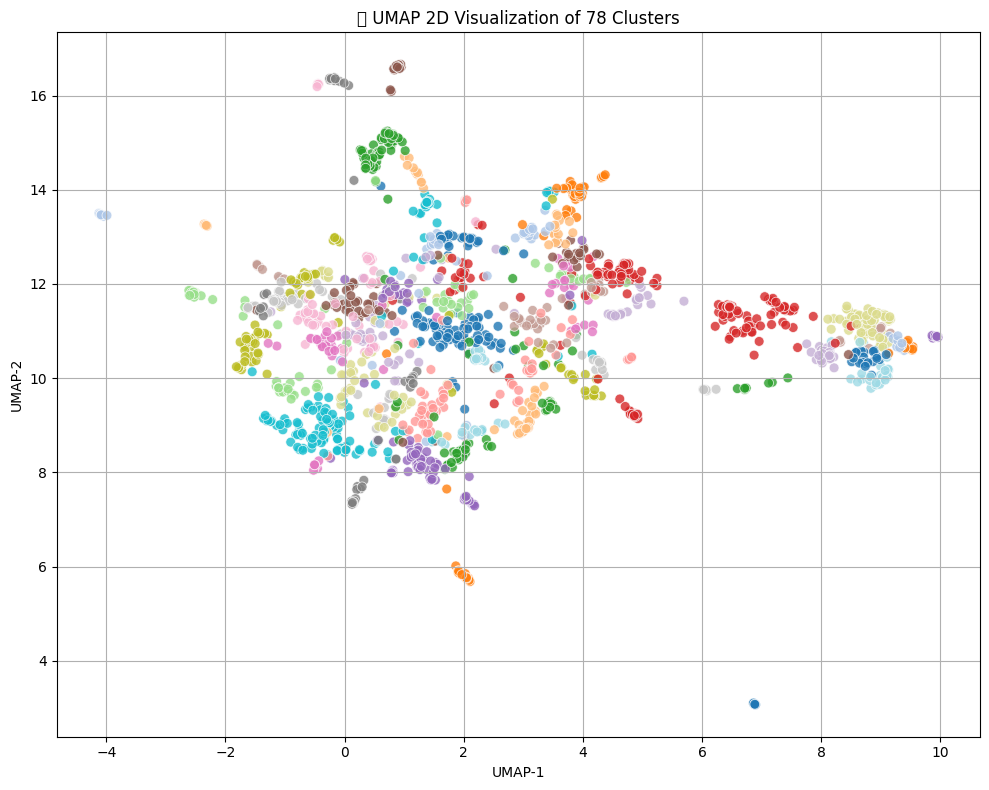

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap

# Reduce embeddings for visualization
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
embeddings_2d = umap_2d.fit_transform(embeddings)

# Plot setup
df["x"] = embeddings_2d[:, 0]
df["y"] = embeddings_2d[:, 1]

num_clusters = len(set(merged_labels))
palette = sns.color_palette("tab20", n_colors=min(num_clusters, 20))
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="x", y="y", hue="Cluster", data=df,
    palette=palette, legend=False, s=50, alpha=0.8
)
plt.title(f"📌 UMAP 2D Visualization of {num_clusters} Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.tight_layout()
plt.show()


Try the clustering using MiniLM and HBDSCAN while including rthema during clustering


By including the rthema, the clusters got slightly worse and the amount of clusters grew a lot. 

In [1]:
#%pip install sentence-transformers hdbscan umap-learn scikit-learn nltk

In [4]:
import re
import numpy as np
import pandas as pd
import nltk
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import hdbscan
import umap

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('german'))

# Load and clean questions
with open("competency_questions_output/competency_questions_200_documents.txt", "r", encoding="utf-8") as f:
    content = f.read()

documents = re.split(r'Dokument:\s*\d+\.xml', content)
questions = []
cleaned_questions = []


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

for block in documents:
    block = block.strip()
    if not block:
        continue

    # Extract Rechtsthema
    m = re.search(r'Rechtsthema:\s*(.+)', block)
    rechtsthema = m.group(1).strip() if m else ""

    # Extract all questions
    frage_blocks = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', block, re.DOTALL)
    for frage in frage_blocks:
        full_text = f"{rechtsthema}. {frage}"
        questions.append(full_text)

        cleaned = remove_stopwords(clean_text(full_text))
        cleaned_questions.append(cleaned)


cleaned_questions = [remove_stopwords(clean_text(q)) for q in questions]

# Embed with MiniLM
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(questions, show_progress_bar=True)

# UMAP before clustering
umap_reducer = umap.UMAP(n_neighbors=15, n_components=10, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(embeddings)

# Run HDBSCAN on reduced space 
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
labels = clusterer.fit_predict(reduced_embeddings)

# Reassign noise (-1) points to nearest cluster in original embedding space 
non_noise_indices = [i for i, l in enumerate(labels) if l != -1]
noise_indices = [i for i, l in enumerate(labels) if l == -1]

non_noise_embeddings = np.array(embeddings)[non_noise_indices]
non_noise_labels = np.array(labels)[non_noise_indices]
noise_embeddings = np.array(embeddings)[noise_indices]

reassigned_labels = []
for i, embed in enumerate(noise_embeddings):
    sims = cosine_similarity([embed], non_noise_embeddings)[0]
    best_idx = np.argmax(sims)
    best_label = non_noise_labels[best_idx]
    reassigned_labels.append(best_label)

final_labels = labels.copy()
for idx, new_label in zip(noise_indices, reassigned_labels):
    final_labels[idx] = new_label

# Merge overly similar clusters based on centroid similarity (optional) 
cluster_dict = {}
for i, label in enumerate(final_labels):
    cluster_dict.setdefault(label, []).append(embeddings[i])

centroids = {label: np.mean(vecs, axis=0) for label, vecs in cluster_dict.items()}
labels_list = list(centroids.keys())
centroid_matrix = np.array([centroids[l] for l in labels_list])
similarity_matrix = cosine_similarity(centroid_matrix)

threshold = 0.95
label_map = {l: l for l in labels_list}
for i in range(len(labels_list)):
    for j in range(i + 1, len(labels_list)):
        if similarity_matrix[i, j] > threshold:
            src = labels_list[j]
            tgt = labels_list[i]
            for k, v in label_map.items():
                if v == src:
                    label_map[k] = tgt
            label_map[src] = tgt

merged_labels = [label_map[l] for l in final_labels]

# TF-IDF cluster labeling 
df = pd.DataFrame({
    "Question": questions,
    "CleanQuestion": cleaned_questions,
    "Cluster": merged_labels
})

cluster_keywords = {}
for label in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == label]["CleanQuestion"]
    if len(group) < 2:
        cluster_keywords[label] = [f"Cluster {label}"]
        continue
    vectorizer = TfidfVectorizer(max_features=5)
    tfidf = vectorizer.fit_transform(group)
    top_words = vectorizer.get_feature_names_out()
    cluster_keywords[label] = top_words.tolist()

df["ClusterLabel"] = df["Cluster"].apply(lambda x: ", ".join(cluster_keywords.get(x, [f"Cluster {x}"])))

# Evaluation 
sil = silhouette_score(embeddings, merged_labels)
db = davies_bouldin_score(embeddings, merged_labels)
ch = calinski_harabasz_score(embeddings, merged_labels)

print("\n📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):")
print(f"- Silhouette Score:        {sil:.3f}")
print(f"- Davies-Bouldin Score:    {db:.3f}")
print(f"- Calinski-Harabasz Score: {ch:.3f}")
print(f"- Num Clusters:            {len(set(merged_labels))}")

# Show sample clusters 
print("\n🧠 Cluster Samples:")
for label in sorted(df["Cluster"].unique())[:5]:
    label_text = cluster_keywords.get(label, f"Cluster {label}")
    preview = df[df["Cluster"] == label]["Question"].head(3).tolist()
    print(f"\n📂 Cluster {label} → Label: {', '.join(label_text)}")
    for q in preview:
        print(f"   - {q}")


[nltk_data] Downloading package stopwords to /Users/jule/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):
- Silhouette Score:        0.050
- Davies-Bouldin Score:    2.348
- Calinski-Harabasz Score: 17.932
- Num Clusters:            84

🧠 Cluster Samples:

📂 Cluster 0 → Label: allgemeinen, geschäftsbedingungen, reisevertrag, schadensersatz, schuldrechtat
   - Schadensersatz, SchuldrechtAT, Zivilverfahrensrecht. Welche Voraussetzungen müssen erfüllt sein, damit ein Frachtführer für den Verlust von Diapositiven während des Transports haften muss?
   - Schadensersatz, SchuldrechtAT, Reisevertrag. Welche Voraussetzungen müssen erfüllt sein, damit eine Reise als vereitelt gilt und eine Entschädigung fällig wird?
   - Schadensersatz, SchuldrechtAT, Reisevertrag. Wer ist verpflichtet, Abhilfe zu leisten, wenn eine Reise vereitelt wird?

📂 Cluster 1 → Label: kläger, patent, patentnichtigkeitsklage, patentnichtigkeitsverfahren, zivilverfahrensrecht
   - Zivilverfahrensrecht. Welche Voraussetzungen müssen erfüllt sein, dami

Try if clustering at first for the rthema and then cluster those rthema clusters again, enhance the outcome.


Worst outcome ever... would have expected a good fit tbh. But possible explanations that we have thought of as well before: the thema are too broad and by splitting by topic before clustering natural similiarities might have been prevented

In [14]:
# %pip install sentence-transformers hdbscan umap-learn scikit-learn nltk

import re
import numpy as np
import pandas as pd
import nltk
from collections import defaultdict
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import hdbscan
import umap

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('german'))

# Load & parse Rechtsthema blocks 
with open("competency_questions_output/competency_questions_200_documents.txt", "r", encoding="utf-8") as f:
    content = f.read()

documents = re.split(r'Dokument:\s*\d+\.xml', content)
rechtsthema_groups = defaultdict(list)

for block in documents:
    block = block.strip()
    if not block:
        continue

    m = re.search(r'Rechtsthema:\s*(.+)', block)
    rechtsthema = m.group(1).strip() if m else "Unbekannt"

    frage_blocks = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', block, re.DOTALL)
    for frage in frage_blocks:
        rechtsthema_groups[rechtsthema].append(frage.strip())

#  Helper functions 
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stop_words])

# Load Sentence Embedding Model - MiniLM
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

all_questions = []
all_labels = []
all_clusters = []
all_rechtsthema = []
label_offset = 0  # ensures unique cluster IDs across topics

print("\n🔍 Clustering separately per Rechtsthema:")

for rechtsthema, questions in rechtsthema_groups.items():
    if len(questions) < 5:
        continue  # skip small groups

    cleaned = [remove_stopwords(clean_text(q)) for q in questions]
    embeddings = model.encode(questions, show_progress_bar=False)

    n_samples = len(embeddings)
    if n_samples < 5:
        continue  # still skip too small clusters safely

    n_components = min(5, max(2, n_samples // 2))  # ensures 2 ≤ n_components < n_samples
    n_neighbors = min(15, n_samples - 1)
    
    reducer = umap.UMAP(n_neighbors=n_neighbors, n_components=n_components, metric='cosine', random_state=42)
    reduced = reducer.fit_transform(embeddings)


    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
    labels = clusterer.fit_predict(reduced)

    # Reassign noise
    non_noise = [i for i, l in enumerate(labels) if l != -1]
    noise = [i for i, l in enumerate(labels) if l == -1]
    non_noise_emb = np.array(embeddings)[non_noise]
    non_noise_labels = np.array(labels)[non_noise]
    noise_emb = np.array(embeddings)[noise]

    final_labels = labels.copy()
    if len(non_noise_emb) > 0:
        for idx, emb in zip(noise, noise_emb):
            sims = cosine_similarity([emb], non_noise_emb)[0]
            best_idx = np.argmax(sims)
            best_label = non_noise_labels[best_idx]
            final_labels[idx] = best_label
    else:
    # If everything was noise, assign dummy cluster ID (offset will fix uniqueness)
        dummy_label = 0
        for idx in noise:
            final_labels[idx] = dummy_label


    # Merge similar clusters
    cluster_dict = {}
    for i, l in enumerate(final_labels):
        cluster_dict.setdefault(l, []).append(embeddings[i])
    centroids = {l: np.mean(v, axis=0) for l, v in cluster_dict.items()}
    label_list = list(centroids.keys())
    sim_matrix = cosine_similarity([centroids[l] for l in label_list])
    label_map = {l: l for l in label_list}
    for i in range(len(label_list)):
        for j in range(i + 1, len(label_list)):
            if sim_matrix[i, j] > 0.95:
                src, tgt = label_list[j], label_list[i]
                for k in label_map:
                    if label_map[k] == src:
                        label_map[k] = tgt
                label_map[src] = tgt
    merged = [label_map[l] for l in final_labels]

    # Store with global label offset
    global_labels = [label_offset + l for l in merged]
    label_offset += max(global_labels) + 1

    all_questions.extend(questions)
    all_labels.extend(global_labels)
    all_rechtsthema.extend([rechtsthema] * len(questions))
    all_clusters.extend([""] * len(questions))  # placeholder

# Evaluation 
X = model.encode(all_questions, show_progress_bar=False)
sil = silhouette_score(X, all_labels)
db = davies_bouldin_score(X, all_labels)
ch = calinski_harabasz_score(X, all_labels)
num_clusters = len(set(all_labels))

# TF-IDF labeling
df = pd.DataFrame({
    "Question": all_questions,
    "Rechtsthema": all_rechtsthema,
    "Cluster": all_labels
})

df["CleanQuestion"] = df["Question"].apply(lambda x: remove_stopwords(clean_text(x)))

cluster_keywords = {}
for label in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == label]["CleanQuestion"]
    if len(group) < 2:
        cluster_keywords[label] = [f"Cluster {label}"]
        continue
    vectorizer = TfidfVectorizer(max_features=5)
    tfidf = vectorizer.fit_transform(group)
    top_words = vectorizer.get_feature_names_out()
    cluster_keywords[label] = top_words.tolist()

df["ClusterLabel"] = df["Cluster"].apply(lambda x: ", ".join(cluster_keywords.get(x, [f"Cluster {x}"])))

# Print Results 
print("\n📊 Final Clustering Evaluation (Grouped by Rechtsthema):")
print(f"- Silhouette Score:        {sil:.3f}")
print(f"- Davies-Bouldin Score:    {db:.3f}")
print(f"- Calinski-Harabasz Score: {ch:.3f}")
print(f"- Num Clusters:            {num_clusters}")

# Preview sample clusters 
print("\n🧠 Cluster Samples:")
for label in sorted(df["Cluster"].unique())[:5]:
    print(f"\n📂 Cluster {label} → Label: {', '.join(cluster_keywords[label])}")
    sample = df[df["Cluster"] == label]["Question"].head(3)
    for q in sample:
        print(f"   - {q}")


[nltk_data] Downloading package stopwords to /Users/jule/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



🔍 Clustering separately per Rechtsthema:


/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to '


📊 Final Clustering Evaluation (Grouped by Rechtsthema):
- Silhouette Score:        -0.052
- Davies-Bouldin Score:    3.345
- Calinski-Harabasz Score: 7.557
- Num Clusters:            101

🧠 Cluster Samples:

📂 Cluster -9124067960564709377 → Label: anwendung, art, bedingungen, nr, richtlinie
   - Welche Voraussetzungen müssen erfüllt sein, damit Art. 2 Nr. 9 der Richtlinie anwendbar ist?
   - Wer ist verpflichtet, die Bedingungen von Art. 2 Nr. 9 der Richtlinie einzuhalten?
   - Wie ist der Begriff 'Verbraucher' in Art. 2 Nr. 9 der Richtlinie definiert?

📂 Cluster -9124067960564709376 → Label: kaufsache, käufer, mangelhafte, verkäufer, zurückweist
   - Wer ist berechtigt, die Abnahme einer mangelhaften Kaufsache zu verweigern?
   - Unter welchen Bedingungen kann ein Käufer eine mangelhafte Kaufsache zurückweisen?
   - Wie kann ein Verkäufer seine Pflicht zur Verschaffung einer mangelfreien Kaufsache erfüllen?

📂 Cluster -8993090321229282817 → Label: 810, anforderungen, anspruchstellers

As including rechtsthema did not improve anything, I sticked to the "best-performing" core pipeline with MiniLM + UMAP + HDBSCAN but used Rechtsthema at the end to refine / interpret small clusters. So as a lightweith post-hoc constraint. 

But also no real improvement compared to the "best-performing" model that does not use rechtsthema in any way - added interpretability but no performance

In [16]:
import re
import numpy as np
import pandas as pd
import nltk
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import hdbscan
import umap

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('german'))

# Load and clean questions 
with open("competency_questions_output/competency_questions_200_documents.txt", "r", encoding="utf-8") as f:
    content = f.read()

questions = list(dict.fromkeys(
    re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', content, re.DOTALL)
))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

cleaned_questions = [remove_stopwords(clean_text(q)) for q in questions]

# Embed with MiniLM 
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(questions, show_progress_bar=True)

# UMAP before clustering 
umap_reducer = umap.UMAP(n_neighbors=15, n_components=10, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(embeddings)

# Run HDBSCAN on reduced space 
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
labels = clusterer.fit_predict(reduced_embeddings)

# Reassign noise (-1) points to nearest cluster in original embedding space 
non_noise_indices = [i for i, l in enumerate(labels) if l != -1]
noise_indices = [i for i, l in enumerate(labels) if l == -1]

non_noise_embeddings = np.array(embeddings)[non_noise_indices]
non_noise_labels = np.array(labels)[non_noise_indices]
noise_embeddings = np.array(embeddings)[noise_indices]

reassigned_labels = []
for i, embed in enumerate(noise_embeddings):
    sims = cosine_similarity([embed], non_noise_embeddings)[0]
    best_idx = np.argmax(sims)
    best_label = non_noise_labels[best_idx]
    reassigned_labels.append(best_label)

final_labels = labels.copy()
for idx, new_label in zip(noise_indices, reassigned_labels):
    final_labels[idx] = new_label

# Merge overly similar clusters based on centroid similarity (optional) 
cluster_dict = {}
for i, label in enumerate(final_labels):
    cluster_dict.setdefault(label, []).append(embeddings[i])

centroids = {label: np.mean(vecs, axis=0) for label, vecs in cluster_dict.items()}
labels_list = list(centroids.keys())
centroid_matrix = np.array([centroids[l] for l in labels_list])
similarity_matrix = cosine_similarity(centroid_matrix)

threshold = 0.95
label_map = {l: l for l in labels_list}
for i in range(len(labels_list)):
    for j in range(i + 1, len(labels_list)):
        if similarity_matrix[i, j] > threshold:
            src = labels_list[j]
            tgt = labels_list[i]
            for k, v in label_map.items():
                if v == src:
                    label_map[k] = tgt
            label_map[src] = tgt

merged_labels = [label_map[l] for l in final_labels]

# TF-IDF cluster labeling 
df = pd.DataFrame({
    "Question": questions,
    "CleanQuestion": cleaned_questions,
    "Cluster": merged_labels
})

# === Optional: Add Rechtsthema from raw data ===
rechtsthemen = []

# Extract Rechtsthema for each question
blocks = re.split(r'Dokument:\s*\d+\.xml', content)
for block in blocks:
    if not block.strip():
        continue
    rt_match = re.search(r'Rechtsthema:\s*(.+)', block)
    rt = rt_match.group(1).strip() if rt_match else "Unbekannt"
    fragen = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', block, re.DOTALL)
    rechtsthemen.extend([rt] * len(fragen))

# Trim in case there are fewer than expected
rechtsthemen = rechtsthemen[:len(df)]

df["Rechtsthema"] = rechtsthemen

print("\n🔍 Small Clusters by Rechtsthema (n ≤ 3):")
small_clusters = df["Cluster"].value_counts()
for cluster_id, size in small_clusters.items():
    if size <= 3:
        sub = df[df["Cluster"] == cluster_id]
        print(f"\n📂 Cluster {cluster_id} ({size} questions)")
        print("   Dominant Rechtsthema:", sub["Rechtsthema"].mode().values[0])
        for q in sub["Question"].tolist():
            print(f"   - {q}")

cluster_keywords = {}
for label in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == label]["CleanQuestion"]
    if len(group) < 2:
        cluster_keywords[label] = [f"Cluster {label}"]
        continue
    vectorizer = TfidfVectorizer(max_features=5)
    tfidf = vectorizer.fit_transform(group)
    top_words = vectorizer.get_feature_names_out()
    cluster_keywords[label] = top_words.tolist()

df["ClusterLabel"] = df["Cluster"].apply(lambda x: ", ".join(cluster_keywords.get(x, [f"Cluster {x}"])))

# Evaluation 
sil = silhouette_score(embeddings, merged_labels)
db = davies_bouldin_score(embeddings, merged_labels)
ch = calinski_harabasz_score(embeddings, merged_labels)

print("\n📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):")
print(f"- Silhouette Score:        {sil:.3f}")
print(f"- Davies-Bouldin Score:    {db:.3f}")
print(f"- Calinski-Harabasz Score: {ch:.3f}")
print(f"- Num Clusters:            {len(set(merged_labels))}")

# Show sample clusters 
print("\n🧠 Cluster Samples:")
for label in sorted(df["Cluster"].unique())[:5]:
    label_text = cluster_keywords.get(label, f"Cluster {label}")
    preview = df[df["Cluster"] == label]["Question"].head(3).tolist()
    print(f"\n📂 Cluster {label} → Label: {', '.join(label_text)}")
    for q in preview:
        print(f"   - {q}")
        
        




[nltk_data] Downloading package stopwords to /Users/jule/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Batches:   0%|          | 0/54 [00:00<?, ?it/s]

/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



🔍 Small Clusters by Rechtsthema (n ≤ 3):

📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):
- Silhouette Score:        0.060
- Davies-Bouldin Score:    2.367
- Calinski-Harabasz Score: 17.709
- Num Clusters:            78

🧠 Cluster Samples:

📂 Cluster 0 → Label: betreibers, kabelnetzbetreiber, netz, signaldurchleitung, signale
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kabelnetzbetreiber die Signaldurchleitung durch das Netz eines anderen Betreibers verbieten kann?
   - Wer ist verpflichtet, eine angemessene Entschädigung zu zahlen, wenn ein Kabelnetzbetreiber die Duldung der Signaldurchleitung durch sein Netz gewährt?
   - Wie kann ein Kabelnetzbetreiber die Durchleitung unerwünschter Signale durch sein Netz verhindern?

📂 Cluster 1 → Label: kläger, patent, patentnichtigkeitsklage, patentnichtigkeitsverfahren, rechtsschutzmöglichkeit
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kläger eine Patentnichtigkeitsklage erheben darf?


Adding Rechtsthema added no value in terms of performance. But for interpretability it might be worth adding it later on to the created clusters. 
So I added each cluster's dominant rechtsthema and checked the purity of the topc distribution within each cluster.


Reminder: purity_score = (number of times a theme occurs in the cluster) / (total number of topic mentions in the cluster)




In [ ]:
import re
import numpy as np
import pandas as pd
import nltk
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import hdbscan
import umap

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('german'))

# Load and extract questions and rechtsthema
with open("competency_questions_output/competency_questions_200_documents.txt", "r", encoding="utf-8") as f:
    content = f.read()

questions = []
rechtsthemen = []

documents = re.split(r'Dokument:\s*\d+\.xml', content)
for block in documents:
    block = block.strip()
    if not block:
        continue
    rt_match = re.search(r'Rechtsthema:\s*(.+)', block)
    rt = rt_match.group(1).strip() if rt_match else "Unbekannt"
    fragen = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', block, re.DOTALL)
    questions.extend([f.strip() for f in fragen])
    rechtsthemen.extend([rt] * len(fragen))

#  Clean questions 
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

cleaned_questions = [remove_stopwords(clean_text(q)) for q in questions]

#  Embed with MiniLM 
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(questions, show_progress_bar=True)

#  UMAP reduction 
umap_reducer = umap.UMAP(n_neighbors=15, n_components=10, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(embeddings)

#  HDBSCAN clustering 
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
labels = clusterer.fit_predict(reduced_embeddings)

#  Reassign noise points 
non_noise_indices = [i for i, l in enumerate(labels) if l != -1]
noise_indices = [i for i, l in enumerate(labels) if l == -1]
non_noise_embeddings = np.array(embeddings)[non_noise_indices]
non_noise_labels = np.array(labels)[non_noise_indices]
noise_embeddings = np.array(embeddings)[noise_indices]

reassigned_labels = []
for i, embed in enumerate(noise_embeddings):
    sims = cosine_similarity([embed], non_noise_embeddings)[0]
    best_idx = np.argmax(sims)
    best_label = non_noise_labels[best_idx]
    reassigned_labels.append(best_label)

final_labels = labels.copy()
for idx, new_label in zip(noise_indices, reassigned_labels):
    final_labels[idx] = new_label

#  Merge overly similar clusters 
cluster_dict = {}
for i, label in enumerate(final_labels):
    cluster_dict.setdefault(label, []).append(embeddings[i])

centroids = {label: np.mean(vecs, axis=0) for label, vecs in cluster_dict.items()}
labels_list = list(centroids.keys())
centroid_matrix = np.array([centroids[l] for l in labels_list])
similarity_matrix = cosine_similarity(centroid_matrix)

threshold = 0.95
label_map = {l: l for l in labels_list}
for i in range(len(labels_list)):
    for j in range(i + 1, len(labels_list)):
        if similarity_matrix[i, j] > threshold:
            src = labels_list[j]
            tgt = labels_list[i]
            for k, v in label_map.items():
                if v == src:
                    label_map[k] = tgt
            label_map[src] = tgt

merged_labels = [label_map[l] for l in final_labels]

#  Create DataFrame 
df = pd.DataFrame({
    "Question": questions,
    "CleanQuestion": cleaned_questions,
    "Cluster": merged_labels,
    "Rechtsthema": rechtsthemen[:len(questions)]
})

#  TF-IDF cluster labeling 
cluster_keywords = {}
for label in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == label]["CleanQuestion"]
    if len(group) < 2:
        cluster_keywords[label] = [f"Cluster {label}"]
        continue
    vectorizer = TfidfVectorizer(max_features=5)
    tfidf = vectorizer.fit_transform(group)
    top_words = vectorizer.get_feature_names_out()
    cluster_keywords[label] = top_words.tolist()

df["ClusterLabel"] = df["Cluster"].apply(lambda x: ", ".join(cluster_keywords.get(x, [f"Cluster {x}"])))

#  Evaluation 
sil = silhouette_score(embeddings, merged_labels)
db = davies_bouldin_score(embeddings, merged_labels)
ch = calinski_harabasz_score(embeddings, merged_labels)

print("\n📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):")
print(f"- Silhouette Score:        {sil:.3f}")
print(f"- Davies-Bouldin Score:    {db:.3f}")
print(f"- Calinski-Harabasz Score: {ch:.3f}")
print(f"- Num Clusters:            {len(set(merged_labels))}")

# Show dominant Rechtsthema per Cluster 
print("\n📚 Cluster Interpretation by Dominant Rechtsthema:")

cluster_themes = (
    df.groupby("Cluster")["Rechtsthema"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unklar")
)

for cluster_id in sorted(df["Cluster"].unique())[:5]:
    theme = cluster_themes[cluster_id]
    label = cluster_keywords.get(cluster_id, [f"Cluster {cluster_id}"])
    sample = df[df["Cluster"] == cluster_id]["Question"].head(2)
    print(f"\n📂 Cluster {cluster_id} → Label: {', '.join(label)}")
    print(f"   ↪ Dominant Rechtsthema: {theme}")
    for q in sample:
        print(f"   - {q}")

#  Show Cluster Purity by Rechtsthema 
print("\n🧪 Cluster Purity by Rechtsthema (Top 5 Clusters):")

for cluster_id in sorted(df["Cluster"].unique())[:5]:
    sub = df[df["Cluster"] == cluster_id]
    counts = sub["Rechtsthema"].value_counts(normalize=True).round(2)
    print(f"\n📂 Cluster {cluster_id} ({len(sub)} questions):")
    print(counts.to_string())


[nltk_data] Downloading package stopwords to /Users/jule/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):
- Silhouette Score:        0.068
- Davies-Bouldin Score:    2.354
- Calinski-Harabasz Score: 17.633
- Num Clusters:            81

📚 Cluster Interpretation by Dominant Rechtsthema:

📂 Cluster 0 → Label: betreibers, kabelnetzbetreiber, netz, signaldurchleitung, signale
   ↪ Dominant Rechtsthema: Sachenrecht
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kabelnetzbetreiber die Signaldurchleitung durch das Netz eines anderen Betreibers verbieten kann?
   - Wer ist verpflichtet, eine angemessene Entschädigung zu zahlen, wenn ein Kabelnetzbetreiber die Duldung der Signaldurchleitung durch sein Netz gewährt?

📂 Cluster 1 → Label: kläger, patent, patentnichtigkeitsklage, patentnichtigkeitsverfahren, rechtsschutzmöglichkeit
   ↪ Dominant Rechtsthema: Zivilverfahrensrecht
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kläger eine Patentnichtigkeitsklage erheben darf?
   - Wer kann als Kläger in 

Ah found the mistake I think: Rechtsthema were interpreted as one line, thus, the rechtsthema that consist of more than one topic (e.g. schdenersatzAT, Reisevertrag, Schuldrecht) are interpreted as one and not three. So here I split them and each questions gets tagged with multiple rechtsthema if necessary

In [18]:
import re
import numpy as np
import pandas as pd
import nltk
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import hdbscan
import umap
from collections import Counter
from itertools import chain

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('german'))

# Load and extract questions and rechtsthema
with open("competency_questions_output/competency_questions_200_documents.txt", "r", encoding="utf-8") as f:
    content = f.read()

questions = []
rechtsthemen = []

documents = re.split(r'Dokument:\s*\d+\.xml', content)
for block in documents:
    block = block.strip()
    if not block:
        continue
    rt_match = re.search(r'Rechtsthema:\s*(.+)', block)
    if rt_match:
        raw_rts = rt_match.group(1).strip()
        rt_list = [rt.strip() for rt in raw_rts.split(",")]
    else:
        rt_list = ["Unbekannt"]

    fragen = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', block, re.DOTALL)
    questions.extend([f.strip() for f in fragen])
    rechtsthemen.extend([rt_list] * len(fragen))  # store list of topics per question

#  Clean questions 
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

cleaned_questions = [remove_stopwords(clean_text(q)) for q in questions]

#  Embed with MiniLM 
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(questions, show_progress_bar=True)

#  UMAP reduction 
umap_reducer = umap.UMAP(n_neighbors=15, n_components=10, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(embeddings)

#  HDBSCAN clustering 
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
labels = clusterer.fit_predict(reduced_embeddings)

#  Reassign noise points 
non_noise_indices = [i for i, l in enumerate(labels) if l != -1]
noise_indices = [i for i, l in enumerate(labels) if l == -1]
non_noise_embeddings = np.array(embeddings)[non_noise_indices]
non_noise_labels = np.array(labels)[non_noise_indices]
noise_embeddings = np.array(embeddings)[noise_indices]

reassigned_labels = []
for i, embed in enumerate(noise_embeddings):
    sims = cosine_similarity([embed], non_noise_embeddings)[0]
    best_idx = np.argmax(sims)
    best_label = non_noise_labels[best_idx]
    reassigned_labels.append(best_label)

final_labels = labels.copy()
for idx, new_label in zip(noise_indices, reassigned_labels):
    final_labels[idx] = new_label

#  Merge overly similar clusters 
cluster_dict = {}
for i, label in enumerate(final_labels):
    cluster_dict.setdefault(label, []).append(embeddings[i])

centroids = {label: np.mean(vecs, axis=0) for label, vecs in cluster_dict.items()}
labels_list = list(centroids.keys())
centroid_matrix = np.array([centroids[l] for l in labels_list])
similarity_matrix = cosine_similarity(centroid_matrix)

threshold = 0.95
label_map = {l: l for l in labels_list}
for i in range(len(labels_list)):
    for j in range(i + 1, len(labels_list)):
        if similarity_matrix[i, j] > threshold:
            src = labels_list[j]
            tgt = labels_list[i]
            for k, v in label_map.items():
                if v == src:
                    label_map[k] = tgt
            label_map[src] = tgt

merged_labels = [label_map[l] for l in final_labels]

#  Create DataFrame 
df = pd.DataFrame({
    "Question": questions,
    "CleanQuestion": cleaned_questions,
    "Cluster": merged_labels,
    "Rechtsthema": rechtsthemen[:len(questions)]
})

#  TF-IDF cluster labeling 
cluster_keywords = {}
for label in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == label]["CleanQuestion"]
    if len(group) < 2:
        cluster_keywords[label] = [f"Cluster {label}"]
        continue
    vectorizer = TfidfVectorizer(max_features=5)
    tfidf = vectorizer.fit_transform(group)
    top_words = vectorizer.get_feature_names_out()
    cluster_keywords[label] = top_words.tolist()

df["ClusterLabel"] = df["Cluster"].apply(lambda x: ", ".join(cluster_keywords.get(x, [f"Cluster {x}"])))

#  Evaluation 
sil = silhouette_score(embeddings, merged_labels)
db = davies_bouldin_score(embeddings, merged_labels)
ch = calinski_harabasz_score(embeddings, merged_labels)

print("\n📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):")
print(f"- Silhouette Score:        {sil:.3f}")
print(f"- Davies-Bouldin Score:    {db:.3f}")
print(f"- Calinski-Harabasz Score: {ch:.3f}")
print(f"- Num Clusters:            {len(set(merged_labels))}")

# Show dominant Rechtsthema per Cluster 
print("\n📚 Cluster Interpretation by Dominant Rechtsthema:")

cluster_themes = (
    df.groupby("Cluster")["Rechtsthema"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unklar")
)

for cluster_id in sorted(df["Cluster"].unique())[:5]:
    theme = cluster_themes[cluster_id]
    label = cluster_keywords.get(cluster_id, [f"Cluster {cluster_id}"])
    sample = df[df["Cluster"] == cluster_id]["Question"].head(2)
    print(f"\n📂 Cluster {cluster_id} → Label: {', '.join(label)}")
    print(f"   ↪ Dominant Rechtsthema: {theme}")
    for q in sample:
        print(f"   - {q}")

#  Show Cluster Purity by Rechtsthema 
print("\n🧪 Cluster Purity by Rechtsthema (Top 5 Clusters):")

for cluster_id in sorted(df["Cluster"].unique())[:5]:
    sub = df[df["Cluster"] == cluster_id]
    # Flatten all topic lists from sub["Rechtsthema"]
    all_topics = list(chain.from_iterable(sub["Rechtsthema"]))
    counts = pd.Series(all_topics).value_counts(normalize=True).round(2)
    print(f"\n📂 Cluster {cluster_id} ({len(sub)} questions):")
    print(counts.to_string())

[nltk_data] Downloading package stopwords to /Users/jule/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Applications/anaconda3/envs/cq_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



📊 Final Clustering Evaluation (MiniLM + UMAP + HDBSCAN + Reassign + Merge):
- Silhouette Score:        0.068
- Davies-Bouldin Score:    2.354
- Calinski-Harabasz Score: 17.633
- Num Clusters:            81

📚 Cluster Interpretation by Dominant Rechtsthema:

📂 Cluster 0 → Label: betreibers, kabelnetzbetreiber, netz, signaldurchleitung, signale
   ↪ Dominant Rechtsthema: ['Sachenrecht']
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kabelnetzbetreiber die Signaldurchleitung durch das Netz eines anderen Betreibers verbieten kann?
   - Wer ist verpflichtet, eine angemessene Entschädigung zu zahlen, wenn ein Kabelnetzbetreiber die Duldung der Signaldurchleitung durch sein Netz gewährt?

📂 Cluster 1 → Label: kläger, patent, patentnichtigkeitsklage, patentnichtigkeitsverfahren, rechtsschutzmöglichkeit
   ↪ Dominant Rechtsthema: ['Zivilverfahrensrecht']
   - Welche Voraussetzungen müssen erfüllt sein, damit ein Kläger eine Patentnichtigkeitsklage erheben darf?
   - Wer kann als Kl